In [1]:
import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
!nvidia-smi

Fri Jul 10 11:19:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:
import pickle
import numpy as np
import pandas as pd
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [5]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.13
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


In [6]:
DATA_MODES = ['train', 'val', 'test']
DEVICE = torch.device("cuda")

TRAIN_DIR = Path('./data/train/')
TEST_DIR = Path('./data/testset')

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

RESCALE_SIZE = [224, 224]

# Загрузка данных

In [7]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=ab836ba9-730e-4060-95ea-3327aa8f4cab
To: /kaggle/working/journey-springfield.zip
100%|█████████████████████████████████████████| 546M/546M [00:04<00:00, 110MB/s]


In [8]:
!unzip -q /kaggle/working/journey-springfield.zip -d data

In [9]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [10]:
# Кодировать имена персонажей в числовые метки класса и обратно будем при помощи LabelEncoder.
label_encoder = LabelEncoder()
train_val_labels = [path.parent.name for path in train_val_files]
label_encoder.fit(train_val_labels)

LabelEncoder()

In [11]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, stratify=train_val_labels)

### Создаем Datasets и Dataloaders + Augmentstion 

In [12]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        self.files = sorted(files)
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [13]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [14]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
loaders = {'train':train_loader, 'val': val_loader}

### Посмотрим персонажей

In [15]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [16]:
def show_images(n_rows, n_cols, dataset):
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), sharey=True, sharex=True)

  for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0, len(dataset)))
    im_val, label = dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(), label_encoder.inverse_transform([label])[0].split('_')))  
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x)
    fig_x.set_axis_off()
  return None

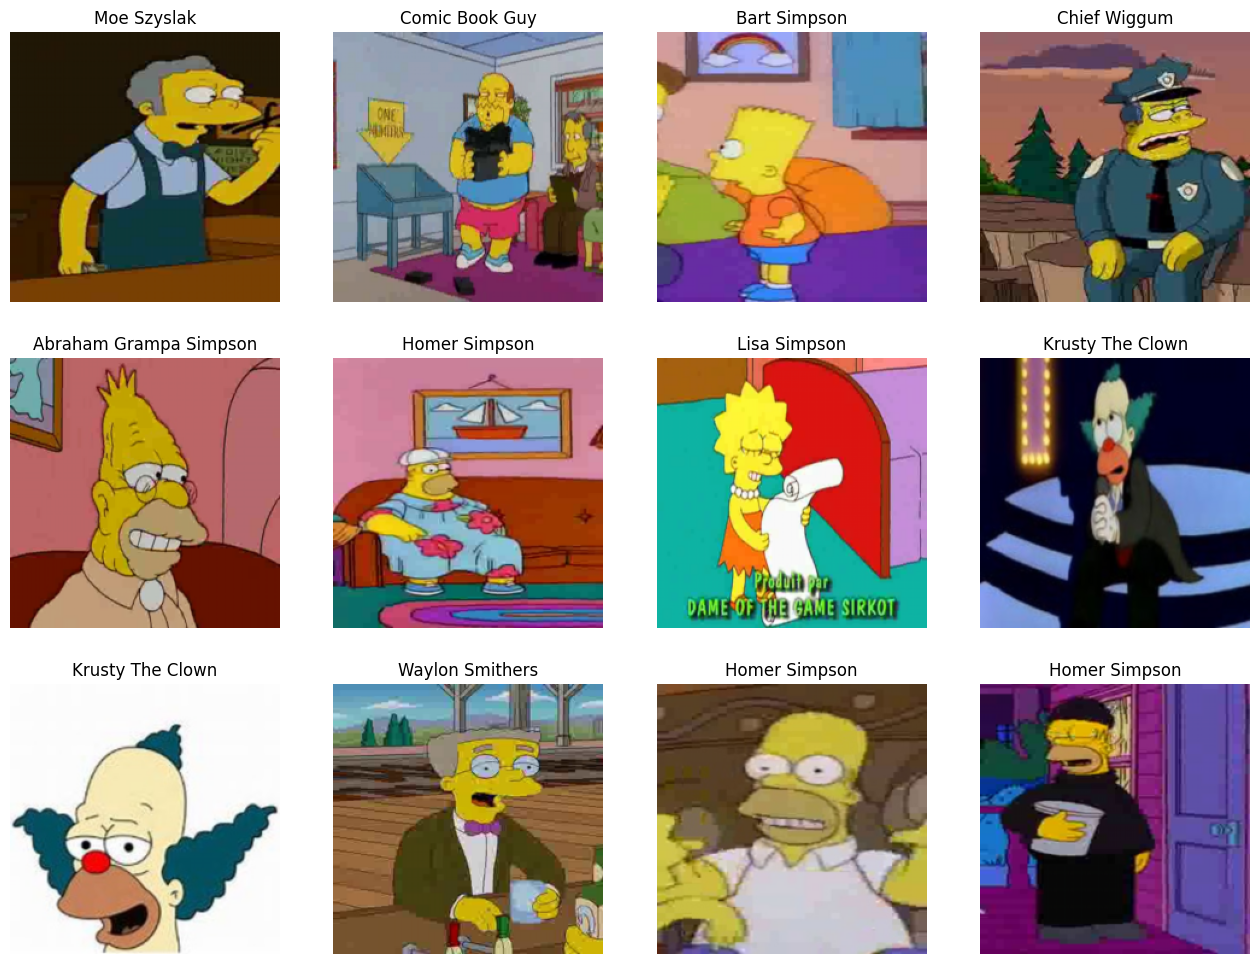

In [17]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

# Построение нейронной сети

In [18]:
class SimpleCnn(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

In [19]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

In [20]:
from sklearn.metrics import f1_score

def count_f1_metrics(y, pred):
    return f1_score(y, pred, average='micro')

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outp.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / len(loader), correct / total

In [22]:
def test_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outp = model(x_batch)
            loss = criterion(outp, y_batch)
            total_loss += loss.item()

            preds = outp.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / len(loader), correct / total


In [23]:
def all_epoch_cycle(model, loaders, optimizer, criterion, max_epochs, device):
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, loaders["train"], optimizer, criterion, device)
        test_loss, test_acc = test_one_epoch(model, loaders["val"], criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")
        print(f"          Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

    return history, max_epochs


In [24]:
def plot_metrics(history, max_epochs):
    epochs = range(1, max_epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Применим модель к данным

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
history, max_epochs = all_epoch_cycle(model_simple_cnn, loaders, optimizer, criterion, max_epochs=10, device=device)

Epoch 1: Train Loss = 2.6895, Test Loss = 1.9431
          Train Acc = 0.2534, Test Acc = 0.4740
Epoch 2: Train Loss = 1.5588, Test Loss = 1.2776
          Train Acc = 0.5744, Test Acc = 0.6504
Epoch 3: Train Loss = 0.9845, Test Loss = 1.0580
          Train Acc = 0.7274, Test Acc = 0.7199
Epoch 4: Train Loss = 0.6829, Test Loss = 0.9222
          Train Acc = 0.8060, Test Acc = 0.7648
Epoch 5: Train Loss = 0.4685, Test Loss = 0.9251
          Train Acc = 0.8654, Test Acc = 0.7778
Epoch 6: Train Loss = 0.3519, Test Loss = 1.0655
          Train Acc = 0.8957, Test Acc = 0.7751
Epoch 7: Train Loss = 0.2517, Test Loss = 1.1009
          Train Acc = 0.9227, Test Acc = 0.7789
Epoch 8: Train Loss = 0.1877, Test Loss = 1.1897
          Train Acc = 0.9421, Test Acc = 0.7807
Epoch 9: Train Loss = 0.1496, Test Loss = 1.3553
          Train Acc = 0.9520, Test Acc = 0.7778
Epoch 10: Train Loss = 0.1311, Test Loss = 1.3291
          Train Acc = 0.9571, Test Acc = 0.7862


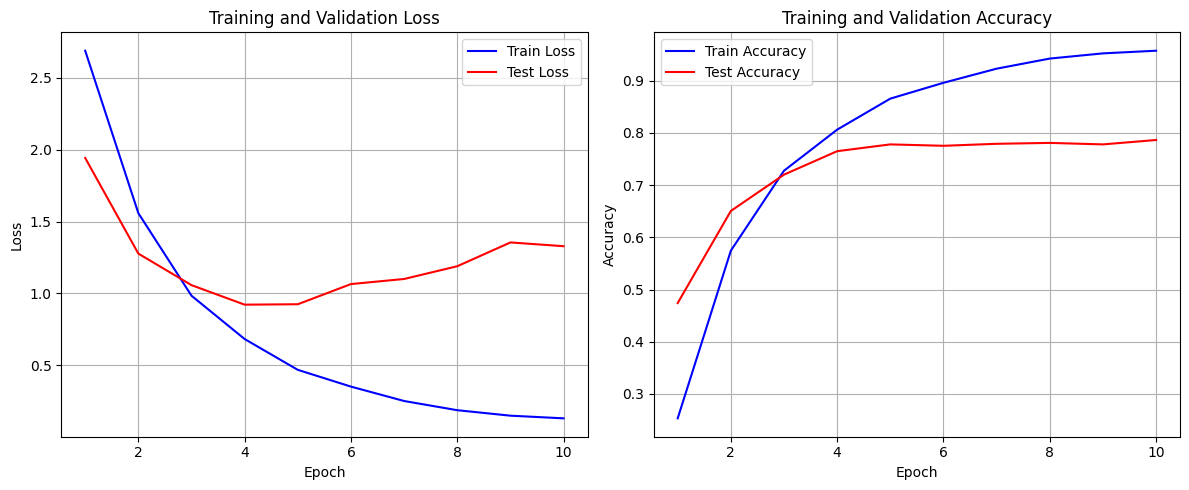

In [28]:
plot_metrics(history, max_epochs)

# Визуализация ответов модели

In [29]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), sharey=True, sharex=True)

  for fig_x in axs.flatten():
    random_characters = int(np.random.uniform(0, len(dataset)))
    im_val, label = dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(), label_encoder.inverse_transform([label])[0].split('_'))) 
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) 

    
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = " ".join(map(lambda x: x.capitalize(), label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

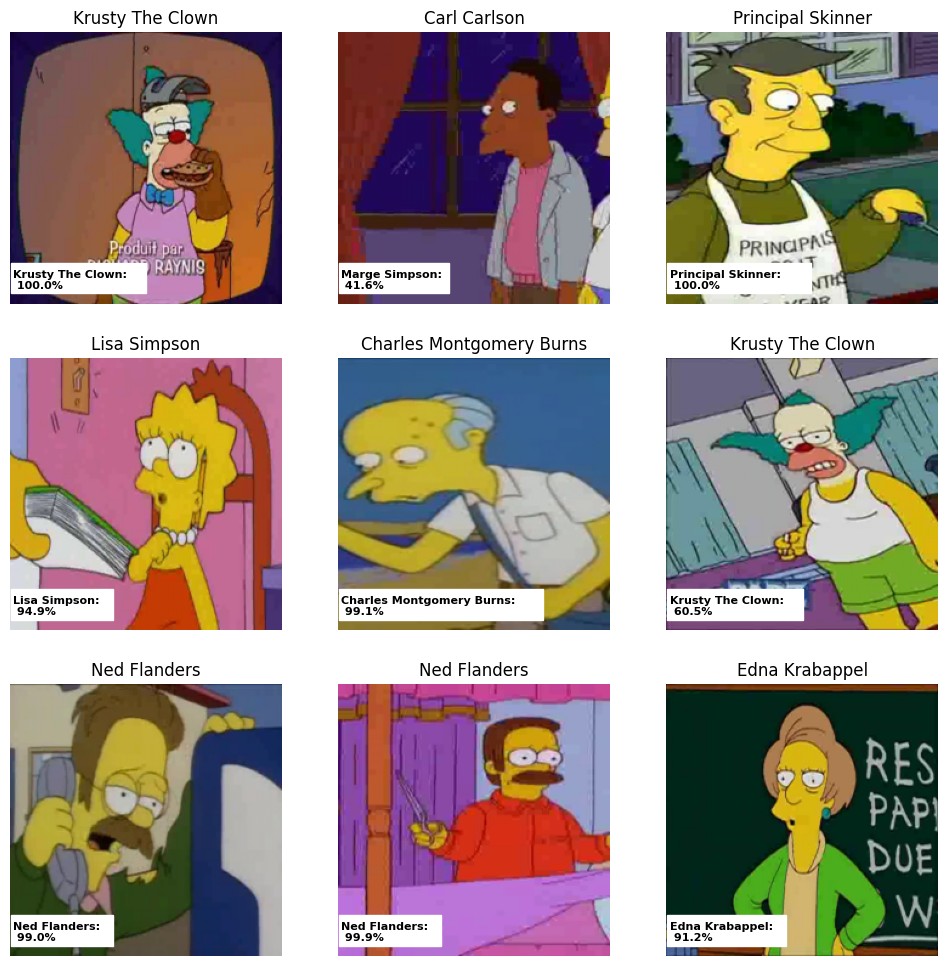

In [30]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

# Смотрим результаты submition

In [31]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

In [32]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

In [33]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [38]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(1)

,Id,Expected
0,img0.jpg,nelson_muntz


In [39]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

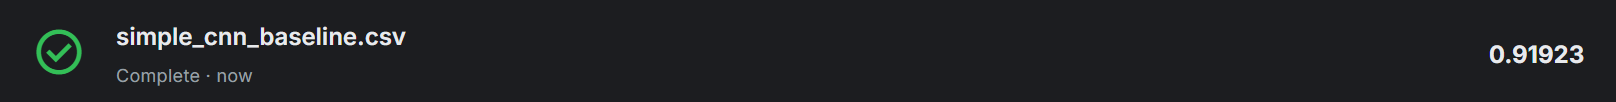
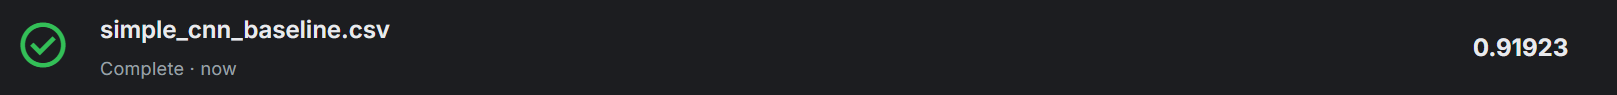
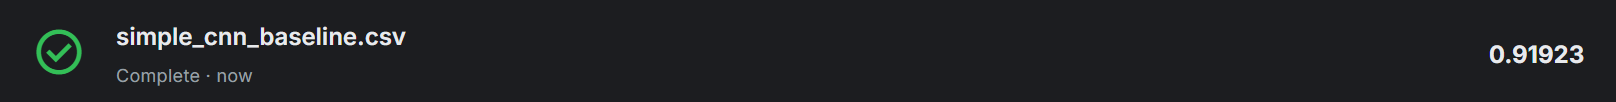